In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


data = pd.read_csv('data/dataset_malware.csv').drop(['Name'], axis=1)

le = LabelEncoder()
for column in data: data[column] = le.fit_transform(data[column])

features = data.drop(['Malware'], axis=1)
labels = data['Malware']

train_features,test_features,train_labels,test_labels = train_test_split(features,labels,test_size = 0.2, random_state=42)


#### Entraînement de modèles

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

#model_classes = [LogisticRegression, DecisionTreeClassifier, RandomForestClassifier]
model_classes = [KNeighborsClassifier, LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, SVC, GaussianNB]

In [14]:
!pip install tqdm
from tqdm import tqdm
import time

models = []

for model in tqdm(model_classes):    
    classifier = model()

    start_time = time.time()
    classifier = classifier.fit(train_features, train_labels)
    train_time = time.time() - start_time

    start_time = time.time()
    predicted_labels = classifier.predict(test_features)
    predict_time = time.time() - start_time

    accuracy = accuracy_score(test_labels, predicted_labels)

    models.append({
        'model_name': model.__name__,
        'model': classifier,
        'predictions': predicted_labels,
        'accuracy': accuracy,
        'train_time': train_time,
        'predict_time_total': predict_time,
        'predict_time_single_in_milliseconds': predict_time / len(test_features) * 1000,
        'predict_throughtput_per_second': len(test_features) / predict_time,
    })

 17%|█▋        | 1/6 [00:01<00:05,  1.05s/it]c:\Users\Lucas\8IAR805---Cybersecurity-AI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
100%|██████████| 6/6 [00:11<00:00,  1.87s/it]


In [15]:
# analyse de la performance des modèles : partie 1
results = pd.DataFrame(models)
results[['model', 'accuracy', 'train_time', 'predict_time_total']].sort_values(by='accuracy', ascending=False)

,model,accuracy,train_time,predict_time_total
3,"(DecisionTreeClassifier(max_features='sqrt', r...",0.992353,2.835012,0.058416
2,DecisionTreeClassifier(),0.985725,0.516794,0.004793
0,KNeighborsClassifier(),0.973745,0.016780,1.035536
4,SVC(),0.947744,4.593580,1.646439
1,LogisticRegression(),0.884527,0.416584,0.004530
5,GaussianNB(),0.598267,0.037047,0.010293


In [16]:
# analyse de la performance des modèles : complète
results = pd.DataFrame(models)
results.drop(['predictions'], axis=1).sort_values(by='accuracy', ascending=False)

,model_name,model,accuracy,train_time,predict_time_total,predict_time_single_in_milliseconds,predict_throughtput_per_second
3,RandomForestClassifier,"(DecisionTreeClassifier(max_features='sqrt', r...",0.992353,2.835012,0.058416,0.014891,67155.837137
2,DecisionTreeClassifier,DecisionTreeClassifier(),0.985725,0.516794,0.004793,0.001222,818456.754477
0,KNeighborsClassifier,KNeighborsClassifier(),0.973745,0.016780,1.035536,0.263965,3788.375203
4,SVC,SVC(),0.947744,4.593580,1.646439,0.419689,2382.717642
1,LogisticRegression,LogisticRegression(),0.884527,0.416584,0.004530,0.001155,866058.981631
5,GaussianNB,GaussianNB(),0.598267,0.037047,0.010293,0.002624,381132.553322


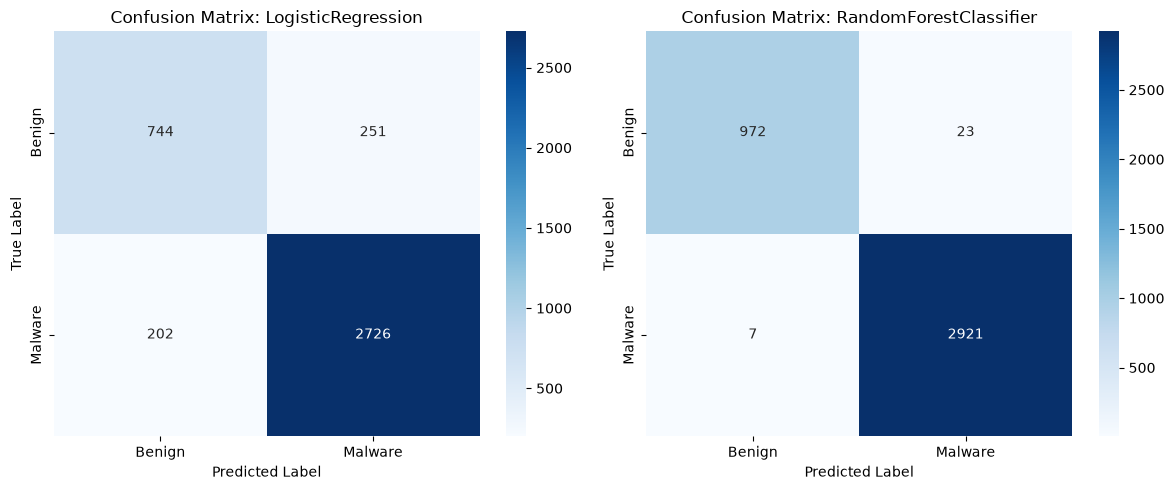

In [20]:
# analyse du niveau de risque par modèle 

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

chosen_models = ['LogisticRegression', 'RandomForestClassifier']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Class 0: Benign, Class 1: Malware
labels = ['Benign', 'Malware']

for idx, model in enumerate(chosen_models):
    y_pred = results[results['model_name'] == model]['predictions'].values[0]
    cm = confusion_matrix(test_labels, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=labels, yticklabels=labels)
    
    axes[idx].set_title(f'Confusion Matrix: {model}')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Verdict : Meilleur modèle
Taille de jeu de données : 6.7 Mo en format csv.

Modèle : 

Accuracy : 
Risque : 
Besoin : 77 colonnes.

Temps d'exécution : secondes pour 19611 prédictions, soit par prédiction.

Pouvoir explicatif : 

In [24]:
import os
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

target = 'RandomForestClassifier'  # Change this to the model you want to visualize # Avec les model d'arbre on peut extraire le raisonnement et passer du probabilisme vers le déterminisme
final_model = next(item['model'] for item in models if item['model_name'] == target)

# Select estimator if Random Forest; otherwise use final_model directly
tree = final_model.estimators_[0] if hasattr(final_model, 'estimators_') else final_model

plt.figure(figsize=(100, 50))
plot_tree(
    tree,
    feature_names=train_features.columns,
    class_names=['Benign', 'Malware'],
    filled=True,
    max_depth=3
)
plt.title("Tree Visualization")

# Save to current working directory
output_path = os.path.join(os.getcwd(), 'tree_visualization.png')
plt.savefig(output_path, dpi=100, bbox_inches='tight')
plt.close()

In [21]:
from sklearn.tree import export_text

# Generate text rules
tree_rules = export_text(
    tree,
    feature_names=list(train_features.columns),
    show_weights=True
)

# Write to a file in the current working directory
file_path = os.path.join(os.getcwd(), 'tree_rules.txt')
with open(file_path, 'w', encoding='utf-8') as f:
    f.write(tree_rules)

In [22]:
from sklearn.tree import _tree

def tree_to_code(tree, feature_names, file_path):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    with open(file_path, "w", encoding="utf-8") as f:
        f.write("def predict(sample):\n")

        def recurse(node, depth):
            indent = "    " * depth
            if tree_.feature[node] != _tree.TREE_UNDEFINED:
                name = feature_name[node]
                threshold = tree_.threshold[node]
                f.write(f"{indent}if sample['{name}'] <= {threshold:.6f}:\n")
                recurse(tree_.children_left[node], depth + 1)
                f.write(f"{indent}else:\n")
                recurse(tree_.children_right[node], depth + 1)
            else:
                # Class 0: Benign, Class 1: Malware
                prediction = int(tree_.value[node].argmax())
                f.write(f"{indent}return {prediction}  # 0: Benign, 1: Malware\n")

        recurse(0, 1)

output_file = os.path.join(os.getcwd(), 'decision_rules.py')
tree_to_code(tree, list(train_features.columns), output_file)

# À faire : 
1. Exécutez le même code. Avez-vous eu le même résultats que moi?

2. êtes-vous capables de faire sortir le raisonnement des autres modèles? Si oui, comment l'expliqueriez-vous à votre supérieur?

In [25]:
import numpy as np
import pandas as pd

# Récupérer le modèle de régression logistique
logreg = results.loc[
    results['model_name'] == 'LogisticRegression',
    'model'
].iloc[0]

# Coefficients associés aux caractéristiques
coefficients = pd.DataFrame({
    'feature': train_features.columns,
    'coefficient': logreg.coef_[0],
    'odds_ratio': np.exp(logreg.coef_[0])
})

coefficients = coefficients.sort_values(
    by='coefficient',
    ascending=False
)

coefficients

,feature,coefficient,odds_ratio
67,SectionMaxChar,0.007502,1.007530
41,SizeOfHeaders,0.004345,1.004354
31,BaseOfCode,0.004229,1.004238
16,e_lfanew,0.004187,1.004195
28,SizeOfInitializedData,0.002768,1.002772
...,...,...,...
32,ImageBase,-0.002329,0.997673
71,DirectoryEntryExport,-0.004617,0.995394
57,SectionMinRawsize,-0.004644,0.995366
43,SizeOfImage,-0.005618,0.994398


In [26]:
probabilities = logreg.predict_proba(test_features.iloc[[0]])

print("Probabilité Benign :", probabilities[0][0])
print("Probabilité Malware :", probabilities[0][1])
print("Classe prédite :", logreg.predict(test_features.iloc[[0]])[0])

Probabilité Benign : 0.7250822657365625
Probabilité Malware : 0.27491773426343746
Classe prédite : 0
